In [145]:
# os 환경 변수 GEMINI API KEY 입력
from dotenv import load_dotenv

load_dotenv()

True

# Dynamic Interrupt
[Interrupt 공식 문서](https://image.png)

## Basic

### Model 정의

In [146]:
from langchain.chat_models import init_chat_model

model = init_chat_model("gpt-5-nano")

### State 정의

In [147]:
from langchain.messages import AnyMessage
from typing_extensions import TypedDict, Annotated
from langgraph.graph.message import add_messages

class ChatState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    context: dict  # 수집된 정보를 저장할 공간

### Node 정의

In [148]:
from langchain.messages import SystemMessage
from langgraph.types import interrupt

def agent_node(state: ChatState):
    # 1. Context에서 정보 확인
    # state에 context 키가 없으면 빈 딕셔너리 생성
    ctx = state.get("context", {})
    food_category = ctx.get("food_category")

    # 2. [Dynamic Interrupt] 정보가 없으면 멈추고 물어봄
    if not food_category:
        print("⏸️ [System] 음식 종류 정보 부재. 사용자에게 질의(Interrupt) 시도...")

        # 실행 중단(Suspend)
        food_category = interrupt('당신은 지금 어떤 종류의 음식을 먹고 싶으신건가요? (예: 한식, 중식, 일식)')


    # 3. [LLM Generation] 확보된 정보로 실제 추천 생성
    system_prompt = SystemMessage(content=f"""
    당신은 서울의 맛집 전문가입니다.
    사용자가 원하는 카테고리인 '{food_category}'에 맞춰서
    실제로 유명한 맛집 1곳을 추천하고, 추천 이유를 2문장으로 설명해주세요.
    """)

    # 기존 대화 내역 + 시스템 프롬프트 조합
    messages = [system_prompt] + state["messages"]
    response = model.invoke(messages)

    # 4. 결과 반환 (메시지 추가 및 Context 업데이트)
    return {
        "messages": [response],
        "context": {"food_category": food_category} # 다음 턴을 위해 정보 저장
    }

### 그래프 생성

In [149]:
from langgraph.graph import StateGraph, START, END

workflow = StateGraph(ChatState)

workflow.add_node("chatbot", agent_node)
workflow.add_edge(START, "chatbot")
workflow.add_edge("chatbot", END)

In [150]:
# InMemorySaver
from langgraph.checkpoint.memory import InMemorySaver

memory = InMemorySaver()

In [151]:
app = workflow.compile(checkpointer=memory)

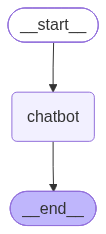

In [152]:
app

In [153]:
config_1 = {"configurable": {"thread_id": "1"}}

In [154]:
from langchain.messages import HumanMessage

input_msg1 = {
    "messages": [HumanMessage(content="강남역 근처 맛집 추천해줘.")],
    "context" : {}
}

response1 = app.invoke(input_msg1, config=config_1)

⏸️ [System] 음식 종류 정보 부재. 사용자에게 질의(Interrupt) 시도...


In [155]:
response1

{'messages': [HumanMessage(content='강남역 근처 맛집 추천해줘.', additional_kwargs={}, response_metadata={}, id='97aa962b-3181-4020-8a16-498567562a51')],
 'context': {},
 '__interrupt__': [Interrupt(value='당신은 지금 어떤 종류의 음식을 먹고 싶으신건가요? (예: 한식, 중식, 일식)', id='1884d9a8d2e556307ed73c570540b1af')]}

In [156]:
# 현재 그래프 상태 확인 (무엇을 기다리는지)
snapshot = app.get_state(config_1)
if snapshot.next:
    print(f"\n⚠️ 그래프 상태: {snapshot.next} (Interrupt 대기 중)")
    print(f"❓ 질문 내용: {snapshot.tasks[0].interrupts[0].value}")


⚠️ 그래프 상태: ('chatbot',) (Interrupt 대기 중)
❓ 질문 내용: 당신은 지금 어떤 종류의 음식을 먹고 싶으신건가요? (예: 한식, 중식, 일식)


In [157]:
# 사용자가 UI에서 "일식"이라고 입력했다고 가정
from langgraph.types import Command

resume_command = Command(resume = '일식')

#### [Command](https://reference.langchain.com/python/langgraph/types/?h=command#langgraph.types.Command)

In [158]:
result_2 = app.invoke(resume_command, config=config_1)

⏸️ [System] 음식 종류 정보 부재. 사용자에게 질의(Interrupt) 시도...


In [159]:
result_2

{'messages': [HumanMessage(content='강남역 근처 맛집 추천해줘.', additional_kwargs={}, response_metadata={}, id='97aa962b-3181-4020-8a16-498567562a51'),
  AIMessage(content='추천 맛집: 스시조 강남점\n\n강남역에서 도보로 쉽게 찾을 수 있는 인기 있는 일식당으로, 신선한 제철 재료로 만든 스시가 특징입니다. 정교한 손질과 안정적인 품질로 많은 방문객들에게 높은 만족도를 얻으며 분위기도 깔끔하고 서비스도 안정적입니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 2390, 'prompt_tokens': 76, 'total_tokens': 2466, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 2304, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-EC16mL7ITDysKYMilLMbwmIXUhiy1', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019ff5a8-b894-7f73-93ea-cec1ef247d34-0', tool_calls=[], invalid_tool_calls=[], usage_metada

In [160]:
result_2['messages'][-1].content

'추천 맛집: 스시조 강남점\n\n강남역에서 도보로 쉽게 찾을 수 있는 인기 있는 일식당으로, 신선한 제철 재료로 만든 스시가 특징입니다. 정교한 손질과 안정적인 품질로 많은 방문객들에게 높은 만족도를 얻으며 분위기도 깔끔하고 서비스도 안정적입니다.'

In [161]:
input_msg2 = {
    "messages": [HumanMessage(content="부산역 근처 맛집 추천해줘.")],
}

response3 = app.invoke(input_msg2, config=config_1)

In [162]:
response3

{'messages': [HumanMessage(content='강남역 근처 맛집 추천해줘.', additional_kwargs={}, response_metadata={}, id='97aa962b-3181-4020-8a16-498567562a51'),
  AIMessage(content='추천 맛집: 스시조 강남점\n\n강남역에서 도보로 쉽게 찾을 수 있는 인기 있는 일식당으로, 신선한 제철 재료로 만든 스시가 특징입니다. 정교한 손질과 안정적인 품질로 많은 방문객들에게 높은 만족도를 얻으며 분위기도 깔끔하고 서비스도 안정적입니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 2390, 'prompt_tokens': 76, 'total_tokens': 2466, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 2304, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-EC16mL7ITDysKYMilLMbwmIXUhiy1', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019ff5a8-b894-7f73-93ea-cec1ef247d34-0', tool_calls=[], invalid_tool_calls=[], usage_metada

## Interrupts in tools

### Model & Tool 정의

In [163]:
from langchain.chat_models import init_chat_model

model = init_chat_model("gpt-5-nano")

In [164]:
from langchain.tools import tool

@tool
def ask_human(question: str) -> str:
    """
    사용자에게 추가 정보를 물어볼 때 사용하는 도구입니다.
    사용자의 답변을 받으려면 이 도구를 호출하세요.
    """

    # 이 함수 본체는 실행되지 않고, 아래 human_node에서 interrupt로 대체
    return "Human input required"

In [165]:
tools = [ask_human]

### State 정의

In [166]:
from langchain.messages import AnyMessage
from typing_extensions import TypedDict, Annotated
from langgraph.graph.message import add_messages

class ChatState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

### Node 정의

In [167]:
# 메인 에이전트 노드
def agent_node(state: ChatState):
    llm_with_tools = model.bind_tools(tools)

    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}

In [168]:
from langchain.messages import ToolMessage
from langgraph.types import interrupt

def human_node(state: ChatState):
    """
    AI가 'ask_human' 도구를 호출했을 때 실행되는 노드입니다.
    실제로 도구를 실행하는 대신, interrupt를 걸어 사용자 입력을 받습니다.
    """
    # 1. AI가 요청한 도구 호출 정보(질문 내용) 가져오기
    last_message = state["messages"][-1]
    tool_call = last_message.tool_calls[0]
    question_to_user = tool_call["args"]["question"]

    # 2. [Dynamic Interrupt]
    user_answer = interrupt(question_to_user)


    # 3. 사용자의 답변을 '도구의 실행 결과(ToolMessage)'인 척 포장해서 return
    return {
        'messages': [
            ToolMessage(content = user_answer,
            tool_call_id = tool_call['id']
            )]

    }

### 그래프 생성

In [169]:
from langgraph.graph import StateGraph, START, END

workflow = StateGraph(ChatState)

workflow.add_node("agent", agent_node)
workflow.add_node("human_node", human_node)

In [170]:
# 조건부 함수
def should_continue(state: ChatState):
    last_message = state["messages"][-1]

    if last_message.tool_calls: 
        return 'human_node'
    else :
        END


In [171]:
# 조건부 엣지
workflow.add_conditional_edges(
    "agent",
    should_continue,
    ["human_node", END]
)

In [172]:
workflow.add_edge(START, "agent")
workflow.add_edge("human_node", "agent") # 답변을 받은 후 다시 에이전트로 돌아가서 생각하게 함

In [173]:
memory = InMemorySaver()

In [174]:
app = workflow.compile(checkpointer=memory)

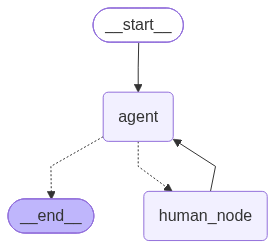

In [175]:
app

In [176]:
thread_config = {"configurable": {"thread_id": "2"}}

In [177]:
from langchain.messages import SystemMessage, HumanMessage

input_data = {
    "messages": [
        SystemMessage(content="당신은 맛집 추천 비서입니다. 위치와 메뉴를 모르면 반드시 도구를 호출해 물어보세요."),
        HumanMessage(content="맛집 추천 좀 해줄래?")
    ]
}

In [178]:
result_1 = app.invoke(input_data, config=thread_config)

In [179]:
result_1

{'messages': [SystemMessage(content='당신은 맛집 추천 비서입니다. 위치와 메뉴를 모르면 반드시 도구를 호출해 물어보세요.', additional_kwargs={}, response_metadata={}, id='7731e4e0-c9ba-4e42-befb-ad9951ec1fdc'),
  HumanMessage(content='맛집 추천 좀 해줄래?', additional_kwargs={}, response_metadata={}, id='d2f54c55-d32e-4981-9da4-dabaac0d62a7'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 862, 'prompt_tokens': 186, 'total_tokens': 1048, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 640, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-EC18SYII7uDwIkFBdskcWxfOc7pIG', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019ff5aa-53eb-73c1-8d9c-18b258c7589b-0', tool_calls=[{'name': 'a

In [180]:
snapshot = app.get_state(thread_config)
snapshot.next

('human_node',)

In [181]:
# 현재 그래프 상태 확인 (무엇을 기다리는지)
snapshot = app.get_state(thread_config)
if snapshot.next:
    # interrupt에 담긴 질문 내용 확인
    # (실제 서비스에선 이걸 프론트엔드로 보냄)
    question = snapshot.tasks[0].interrupts[0].value

In [182]:
question

'맛집 추천 드리려면 몇 가지 정보가 필요해요. 아래를 알려주실 수 있을까요?\n1) 위치/지역: 어떤 도시나 구역에서 찾고 계신가요?\n2) 선호하는 메뉴 혹은 요리 타입: 한식/일식/중식/양식 중 어떤 걸 원하시나요? 특정 메뉴가 있나요?(예: 파스타, 스시, 돼지불고기 등)\n3) 예산: 1인당 대략 어느 정도를 생각하시나요?\n4) 분위기나 상황: 데이트, 가족 모임, 편하게 먹는 자리 등 어떤 분위기를 원하시나요?\n5) 시간대: 점심/저녁 중 어느 때 방문 예정인가요? 예약이 필요하면 알려주세요.\n추가로 알레르기나 식이제한이 있다면 함께 알려주시면 맞춤 추천해 드릴게요.'

In [183]:
from langgraph.types import Command

natural_language_answer = "음... 오늘은 비도 오고 하니까 따뜻한 우동이나 일식 같은 게 먹고 싶어."

# Command 객체를 사용하여 멈춘 지점에 값을 던져줌
resume_command = Command(resume=natural_language_answer)

In [184]:
result_2 = app.invoke(resume_command, config=thread_config)

In [186]:
result_2

{'messages': [SystemMessage(content='당신은 맛집 추천 비서입니다. 위치와 메뉴를 모르면 반드시 도구를 호출해 물어보세요.', additional_kwargs={}, response_metadata={}, id='7731e4e0-c9ba-4e42-befb-ad9951ec1fdc'),
  HumanMessage(content='맛집 추천 좀 해줄래?', additional_kwargs={}, response_metadata={}, id='d2f54c55-d32e-4981-9da4-dabaac0d62a7'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 862, 'prompt_tokens': 186, 'total_tokens': 1048, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 640, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-EC18SYII7uDwIkFBdskcWxfOc7pIG', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019ff5aa-53eb-73c1-8d9c-18b258c7589b-0', tool_calls=[{'name': 'a

In [187]:
result_2['messages'][-1].content

''

## Validating Human Input

### Model & Tool 정의

### State 정의

### Node 정의

In [188]:
# 2. 검증 로직이 포함된 Human Node
def human_validating_node(state: ChatState):
    # 1. AI가 던진 질문 가져오기
    last_message = state["messages"][-1]
    tool_call = last_message.tool_calls[0]
    original_question = tool_call["args"]["question"]

    # 2. 유효한 메뉴 목록 정의
    valid_categories = ["한식", "중식", "일식", "양식", "분식"]

    # 질문 텍스트 초기화
    current_prompt = original_question

    # [무한 루프] 제대로 된 답이 나올 때까지 가둔다.
    while True:
        # A. 멈추고 질문 (또는 에러 메시지와 함께 재질문)
        user_input = interrupt(current_prompt)


        # B. 검증 로직 (Validation)
        # 입력값에 유효 카테고리가 포함되어 있는지 확인
        # (예: "매운 한식 먹을래" -> "한식" 포함 -> 통과)
        if any(category in user_input for category in valid_categories):

            # C. 검증 통과 시 ToolMessage 반환 (루프 탈출)
            return {
                "messages": [
                    ToolMessage(
                        content=user_input,
                        tool_call_id=tool_call["id"]
                    )
                ]
            }

        else:
            # D. 실패 시 프롬프트 수정 후 continue (다시 A로 돌아감)
            print(f"❌ [Fail] 메뉴에 없는 요청입니다.")
            current_prompt = (
                f"죄송합니다. '{user_input}'은(는) 추천해드릴 수 없습니다.\n"
                f"가능한 메뉴는 {valid_categories} 입니다. 다시 말씀해주세요."
            )


In [189]:
# 메인 에이전트 노드
def agent_node(state: ChatState):
    llm_with_tools = model.bind_tools(tools)

    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}

### 그래프 생성

In [190]:
from langgraph.graph import StateGraph, START, END

workflow = StateGraph(ChatState)

workflow.add_node("agent", agent_node)
workflow.add_node("human_node", human_validating_node)

In [191]:
# 조건부 함수
def should_continue(state: ChatState):
    last_message = state["messages"][-1]

    # 도구 호출이 있는데, 그게 'ask_human'이면 사람 노드로 보냄
    if last_message.tool_calls:
        if last_message.tool_calls[0]["name"] == "ask_human":
            return "human_node"

    # 도구 호출이 없으면 종료 (답변 완료)
    return END

In [192]:
workflow.add_conditional_edges(
    "agent",
    should_continue,
    ["human_node", END]
)

In [193]:
workflow.add_edge(START, "agent")
workflow.add_edge("human_node", "agent") # 답변을 받은 후 다시 에이전트로 돌아가서 생각하게 함

In [194]:
app = workflow.compile(checkpointer=memory)

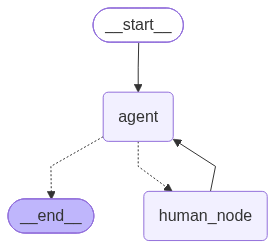

In [195]:
app

In [196]:
thread_config = {"configurable": {"thread_id": "3"}}

In [197]:
from langchain.messages import SystemMessage, HumanMessage

input_data = {
    "messages": [
        SystemMessage(content="당신은 맛집 추천 비서입니다. 위치와 메뉴를 모르면 반드시 도구를 호출해 물어보세요."),
        HumanMessage(content="맛집 추천 좀 해줄래?")
    ]
}

In [198]:
from langchain.messages import SystemMessage, HumanMessage

result_1 = app.invoke(input_data, config=thread_config)

In [199]:
result_1

{'messages': [SystemMessage(content='당신은 맛집 추천 비서입니다. 위치와 메뉴를 모르면 반드시 도구를 호출해 물어보세요.', additional_kwargs={}, response_metadata={}, id='52710bc1-4bbc-4d1c-bbf8-fdbe9d04f4e9'),
  HumanMessage(content='맛집 추천 좀 해줄래?', additional_kwargs={}, response_metadata={}, id='a6c4661e-183a-4be4-97de-0eb5f208a353'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 892, 'prompt_tokens': 186, 'total_tokens': 1078, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 704, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-EC19EQhiw0jJzPPDG8Mu65qnTnguU', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019ff5ab-098c-78d3-b3bd-4d12884c8c69-0', tool_calls=[{'name': 'a

In [200]:
# 현재 그래프 상태 확인 (무엇을 기다리는지)
snapshot = app.get_state(thread_config)
if snapshot.next:
    question = snapshot.tasks[0].interrupts[0].value
    print(f"\n⚠️ [Interrupt 발생] AI의 질문: {question}")


⚠️ [Interrupt 발생] AI의 질문: 맛집 추천을 도와드리려면 몇 가지 정보를 알려주세요.
1) 찾고 계신 지역이나 도시/동네는 어디인가요?
2) 예산은 1인당 어느 정도인가요? (예: 5천원~1만원, 1만~2만원 등)
3) 선호하는 요리 유형이나 분위기는 무엇인가요? (예: 한국식, 일식, 양식, 퓨전, 캐주얼/데이트/가족식당 등)
4) 방문 인원 수와 시간대는 언제인가요? (점심/저녁, 가능하면 날짜도)
5) 식단 제한이나 알레르기, 포장 여부/예약 선호 같은 제약이 있나요?


In [ ]:
app.invoke(Command[tuple[()]](resume="신발 튀김"), config=thread_config)

❌ [Fail] 메뉴에 없는 요청입니다.


{'messages': [SystemMessage(content='당신은 맛집 추천 비서입니다. 위치와 메뉴를 모르면 반드시 도구를 호출해 물어보세요.', additional_kwargs={}, response_metadata={}, id='52710bc1-4bbc-4d1c-bbf8-fdbe9d04f4e9'),
  HumanMessage(content='맛집 추천 좀 해줄래?', additional_kwargs={}, response_metadata={}, id='a6c4661e-183a-4be4-97de-0eb5f208a353'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 892, 'prompt_tokens': 186, 'total_tokens': 1078, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 704, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-EC19EQhiw0jJzPPDG8Mu65qnTnguU', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019ff5ab-098c-78d3-b3bd-4d12884c8c69-0', tool_calls=[{'name': 'a

In [202]:
snapshot = app.get_state(thread_config)
print(f"⚠️ [재질문] 내용: {snapshot.tasks[0].interrupts[0].value}")

⚠️ [재질문] 내용: 죄송합니다. '신발 튀김'은(는) 추천해드릴 수 없습니다.
가능한 메뉴는 ['한식', '중식', '일식', '양식', '분식'] 입니다. 다시 말씀해주세요.


In [207]:
result = app.invoke(Command[tuple[()]](resume="양식"), config=thread_config)

{'messages': [SystemMessage(content='당신은 맛집 추천 비서입니다. 위치와 메뉴를 모르면 반드시 도구를 호출해 물어보세요.', additional_kwargs={}, response_metadata={}, id='52710bc1-4bbc-4d1c-bbf8-fdbe9d04f4e9'),
  HumanMessage(content='맛집 추천 좀 해줄래?', additional_kwargs={}, response_metadata={}, id='a6c4661e-183a-4be4-97de-0eb5f208a353'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 892, 'prompt_tokens': 186, 'total_tokens': 1078, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 704, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-EC19EQhiw0jJzPPDG8Mu65qnTnguU', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019ff5ab-098c-78d3-b3bd-4d12884c8c69-0', tool_calls=[{'name': 'a

In [210]:
result['messages'][-1].content

''